# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy import stats

In [7]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


In [8]:
notas_A = np.array([87.64052346, 74.00157208, 79.78737984, 92.40893199, 88.6755799])
notas_B = np.array([64.25440127, 79.64282997, 68.87033835, 60.83241379, 74.66181326])

media_A = np.mean(notas_A)
media_B = np.mean(notas_B)

variancia_A = np.var(notas_A, ddof=1)
variancia_B = np.var(notas_B, ddof=1)

print(f"Média A: {media_A:.2f} | Variância A: {variancia_A:.2f}")
print(f"Média B: {media_B:.2f} | Variância B: {variancia_B:.2f}")

Média A: 84.50 | Variância A: 55.57
Média B: 69.65 | Variância B: 58.11


Vemos que a média da estratégia A é maior (84.50) à média da estratégia B (69.65), indo contra à idéia de que uma segunda estratégia traria notas melhores. Temos as variâncias com números bem próximos, o que nos mostra que as estratégia A e a estratégia B têm um grau de dispersão semelhante.

In [9]:
#Seu código aqui
t_statistic, p_valor = stats.ttest_ind(amostra_estrategia_A, amostra_estrategia_B)

print("Estatística de teste (t-statistic):", t_statistic)
print("p-valor:", p_valor)

nivel_significancia = 0.05
if p_valor < nivel_significancia:
    print("Rejeitamos a hipótese nula: a nova página de destino tem uma estratégia de ensino significativamente melhor.")
else:
    print("Não temos evidências suficientes para rejeitar a hipótese nula: a nova página de destino não tem uma estratégia de ensino significativamente melhor.")

Estatística de teste (t-statistic): -1.5267455833477102
p-valor: 0.130045389609515
Não temos evidências suficientes para rejeitar a hipótese nula: a nova página de destino não tem uma estratégia de ensino significativamente melhor.


Vemos no valor negativo a queda de desempenho da estratégia A para a estratégia B, o que confirma a análise anterior que não temos evidências estatísticas que a estratégia B seja melhor que a estratégia A.

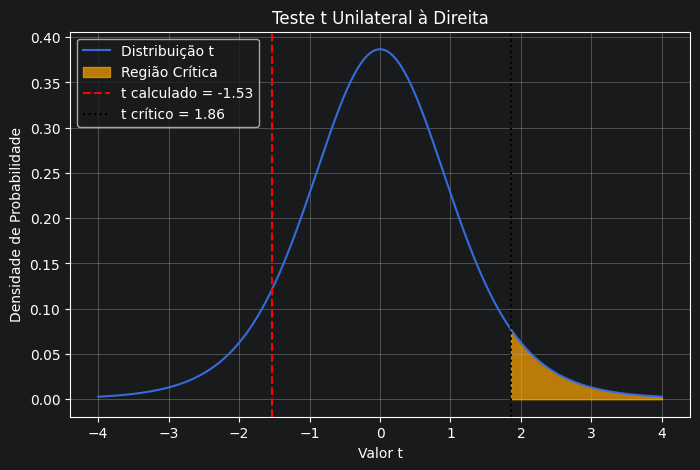

In [10]:
#Seu código aqui
df = len(notas_A) + len(notas_B) - 2
alfa = 0.05
t_calculado = -1.53
t_critico = t.ppf(1 - alfa, df)
x = np.linspace(-4, 4, 500)
y = t.pdf(x, df)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Distribuição t')
x_crit = np.linspace(t_critico, 4, 100)
plt.fill_between(x_crit, t.pdf(x_crit, df), color='orange', alpha=0.7, label='Região Crítica')
plt.axvline(t_calculado, color='red', linestyle='--', label=f't calculado = {t_calculado:.2f}')

plt.axvline(t_critico, color='black', linestyle=':', label=f't crítico = {t_critico:.2f}')
plt.title('Teste t Unilateral à Direita')
plt.xlabel('Valor t')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True)
plt.show()

Vemos no gráfico a distribuição de t com a região crítica, o valor negativo (-1.53) indica que a média da estratégia B foi menor que a estratégia A.